In [2]:
source('lib/lib.R', chdir=T)
pacman::p_load(scTenifoldKnk, anndataR, install=F)

In [3]:
michalski <- read_h5ad('data/Michalski_raw.h5ad') # Download "ScRNA-seq - P8, P12, P20 mouse cochlea (Michalski 2023) - Raw Data" from gEAR portal
mitocarta <- openxlsx::read.xlsx('data/Mouse.MitoCarta3.0.xlsx', sheet=2) # Download from MitoCarta database

coi <- michalski[michalski$obs$`P8-12-20` == 'Deiter\'s cells', ]
seu <- CreateSeuratObject(counts = coi$X, meta.data = coi$obs)
seu <- NormalizeData(seu, normalization.method='RC', scale.factor=1e6) # CPM normalization
X <- t(GetAssayData(seu, layer='data'))

X <- X[!grepl('^mt-|^rp[sl]', coi$var$gene_symbol, ignore.case=T) & !coi$var$gene_symbol %in% mitocarta$Symbol & !rownames(coi$var) %in% mitocarta$EnsemblGeneID & !startsWith(rownames(X), 'NA_'), ] # Exclude mitochondrial, ribosomal, nuclear-encoded mitochondrial genes, pseudogenes (^Gm, Rik$)
X <- X[rowSums(X > 0) >= 0.1 * ncol(X), ] # genes expressed in at least 10% of DCs

# X %>% dim

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Cannot add more or less meta data without cell names”
Normalizing layer: counts



In [81]:
res <- scTenifoldKnk(
    X,
    qc       = F,
    gKO      = 'ENSMUSG00000032092' # Mpzl2
)

saveRDS(res, 'res/Michalski_raw-CPM-scTenifold.rds')



── scTenifoldKnk ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Simulating ENSMUSG00000032092 gene knockout

✔ Network construction complete (nNet = 10, nCells per net = 500)

✔ Tensor decomposition completed (K = 3)

✔ Prepared WT adjacency matrix for KO simulation

✔ Simulated knockout for ENSMUSG00000032092

✔ Manifold alignment completed (d = 2)

✔ Differential regulation computed for ENSMUSG00000032092

✔ Finished scTenifoldKnk for ENSMUSG00000032092



In [18]:
res <- readRDS('res/Michalski_raw-CPM-scTenifold.rds')
res$diffRegulation <- left_join(
    res$diffRegulation,
    coi$var %>% rownames_to_column('gene'),
    by='gene'
) %>% 
    mutate(gene_id = gene, gene = gene_symbol, gene_symbol = NULL) %>%
    relocate(gene_id, .after=gene)

gene_map <- res$diffRegulation %>%
    select(gene_id, gene) %>%
    deframe

rownames(res$tensorNetworks$WT) <- gene_map[rownames(res$tensorNetworks$WT)]
colnames(res$tensorNetworks$WT) <- gene_map[colnames(res$tensorNetworks$WT)]
rownames(res$tensorNetworks$KO) <- gene_map[rownames(res$tensorNetworks$KO)]
colnames(res$tensorNetworks$KO) <- gene_map[colnames(res$tensorNetworks$KO)]

In [20]:
suppressMessages(library(msigdbr))
suppressMessages(library(fgsea))

stat <- res$diffRegulation %>%
    select(gene, Z) %>%
    deframe %>% sort(decreasing = T)

m_t2g <- msigdbr(species='Mus musculus', subcollection='GO:BP') %>%
    dplyr::select(gs_exact_source, gene_symbol, gs_name)

gene_sets_bp <- m_t2g %>%
    group_by(gs_name) %>%
    summarise(genes = list(gene_symbol)) %>%
    deframe()

tenifold_gsea <- fgseaSimple(
    pathways = gene_sets_bp,
    stats = stat,
    scoreType = 'pos',
    minSize = 15,
    maxSize = 300,
    nperm = 10000
)

tenifold_gsea <- tenifold_gsea %>%
    filter(padj < 0.05) %>%
    left_join(
        m_t2g %>%
            distinct(gs_exact_source, gs_name),
        by=c('pathway'='gs_name')
    )

Using human MSigDB with ortholog mapping to mouse. Use `db_species = "MM"` for mouse-native gene sets.
This message is displayed once per session.


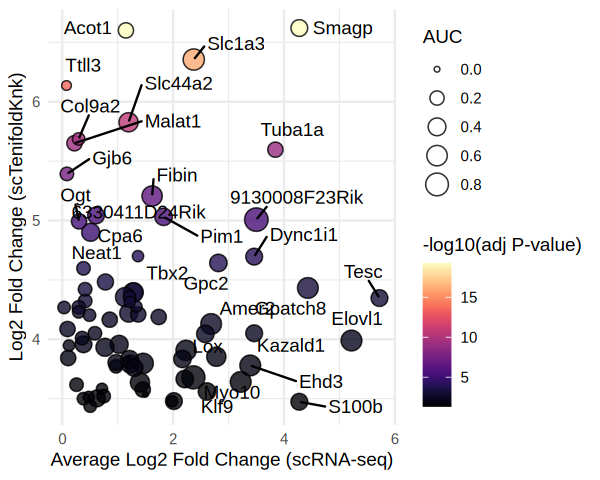

In [179]:
dc_deg <- readRDS('obj/260728_DC_roc_degs.rds')
merged_data <- dc_deg$WT_Uninj %>%
    filter(gene %in% sig_genes) %>%
    left_join(res$diffRegulation, by='gene')

library(ggrepel)
figs(4, 5)
ggplot(merged_data, aes(x=abs(avg_log2FC), y=log2(FC))) +
    geom_point(aes(fill=-log10(p.adj), size=sym_AUC), shape=21, alpha=0.8, stroke=0.5) +
    geom_text_repel(aes(label=gene), box.padding=0.5, max.overlaps=15) +
    scale_fill_viridis(option='magma') +
    theme_minimal() +
    labs(
        x='Average Log2 Fold Change (scRNA-seq)',
        y='Log2 Fold Change (scTenifoldKnk)',
        fill='-log10(adj P-value)',
        size='AUC'
    )

In [21]:
.plotKO_pre <- function(X, gKO, fgsea_res, q = 0.99, annotate = TRUE, nCategories = 20, fdrThreshold = 0.05) {
    suppressMessages(require(pals))
    suppressMessages(require(igraph))
    suppressMessages(require(svglite))
    
    gList <- unique(c(gKO, X$diffRegulation$gene[X$diffRegulation$distance > 1e-10 & X$diffRegulation$p.adj < 0.05]))
    
    if (length(gList) > 0) {
        sCluster <- as.matrix(X$tensorNetworks$WT[gList, gList])
        koInfo <- sCluster[gKO, ]
        gList <- gList[!grepl('^mt-|^Rpl|^Rps', gList, ignore.case = TRUE)]
        sCluster[abs(sCluster) <= quantile(abs(sCluster), q)] <- 0
        sCluster[gKO, ] <- koInfo
        diag(sCluster) <- 0
        sCluster <- reshape2::melt(as.matrix(sCluster))
        colnames(sCluster) <- c('from', 'to', 'W')
        sCluster <- sCluster[sCluster$W != 0, ]
        netPlot <- igraph::graph_from_data_frame(sCluster, directed = TRUE)
        dPlot <- igraph::centr_degree(netPlot)$res
        W <- rep(1, nrow(sCluster))
        sG <- (names(igraph::V(netPlot))[dPlot > 1])[-1]
        W[sCluster$from %in% sG] <- 0.2
        W[sCluster$to %in% sG] <- 0.2
        W[sCluster$from %in% gKO] <- 1
        W[sCluster$from %in% gKO & sCluster$to %in% sG] <- 0.8
        set.seed(1)
        layPlot <- igraph::layout_with_fr(netPlot, weights = W)
        dPlot <- (dPlot / max(dPlot)) * 20
        
        if (isTRUE(annotate)) {
            
            network_genes <- toupper(names(igraph::V(netPlot)))
            
            E_sig <- fgsea_res %>%
                dplyr::filter(padj < fdrThreshold) %>%
                dplyr::rowwise() %>%
                dplyr::mutate(net_genes = list(intersect(toupper(unlist(leadingEdge)), network_genes))) %>%
                dplyr::filter(length(net_genes) > 0) %>%
                dplyr::ungroup() %>%
                dplyr::arrange(padj)
            
            if (nrow(E_sig) > nCategories) {
                selected_idx <- integer(0)
                covered_genes <- character(0)
                
                # Greedy selection to maximize colored genes
                while(length(selected_idx) < nCategories) {
                    new_yields <- sapply(seq_len(nrow(E_sig)), function(i) {
                        if (i %in% selected_idx) return(-1)
                        length(setdiff(E_sig$net_genes[[i]], covered_genes))
                    })
                    
                    max_yield <- max(new_yields)
                    if (max_yield <= 0) break
                    
                    best_idx <- which(new_yields == max_yield)[1]
                    selected_idx <- c(selected_idx, best_idx)
                    covered_genes <- unique(c(covered_genes, E_sig$net_genes[[best_idx]]))
                }
                
                # Fill remaining slots up to nCategories
                if (length(selected_idx) < nCategories) {
                    remaining_idx <- setdiff(seq_len(nrow(E_sig)), selected_idx)
                    slots_left <- nCategories - length(selected_idx)
                    if (length(remaining_idx) > 0) {
                        fill_count <- min(length(remaining_idx), slots_left)
                        selected_idx <- c(selected_idx, remaining_idx[seq_len(fill_count)])
                    }
                }
                
                E <- E_sig[selected_idx, ] %>% dplyr::arrange(padj)
            } else {
                E <- E_sig
            }
            
            if (nrow(E) > 0) {
                tPlot <- lapply(E$leadingEdge, toupper)
                
                pPlot <- matrix(0, nrow = length(igraph::V(netPlot)), ncol = nrow(E))
                rownames(pPlot) <- toupper(names(igraph::V(netPlot)))
                
                for (i in seq_along(tPlot)) {
                    valid_genes <- intersect(unlist(tPlot[i]), rownames(pPlot))
                    if (length(valid_genes) > 0) {
                        pPlot[valid_genes, i] <- 1
                    }
                }
                
                pPlot <- lapply(seq_len(nrow(pPlot)), function(idx) {
                    as.vector(pPlot[idx, ])
                })
                names(pPlot) <- names(igraph::V(netPlot))
                tPlot_flat <- unique(unlist(tPlot))
                eGenes <- toupper(names(igraph::V(netPlot))) %in% tPlot_flat
                vColor <- rgb(195/255, 199/255, 198/255, 0.3)
                
                gb_cols <- pals::glasbey(32)
                gb_cols <- gb_cols[!gb_cols %in% c('#000033', '#201A01')]
                
                if (nrow(E) == 1) {
                    pieColors <- list(gb_cols[1])
                } else {
                    pieColors <- list(gb_cols[1:nrow(E)])
                }
                
                par(mar = c(0, 0, 0, 10), xpd = TRUE, family = 'Arial')
                
                suppressWarnings(plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.shape = ifelse(eGenes, 'pie', 'circle'), vertex.pie = pPlot, vertex.size = 10 + dPlot, vertex.pie.color = pieColors, vertex.label.family = 'Arial', vertex.label.font = ifelse(eGenes, 2, 1), edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = vColor, vertex.frame.color = NA))
                
                sigLevel <- formatC(E$padj, digits = 2, format = 'g', width = 0, drop0trailing = TRUE)
                
                path_names <- gsub('^GOBP_', '', E$pathway)
                path_names <- gsub('_', ' ', path_names)
                path_names <- tolower(path_names)
                substr(path_names, 1, 1) <- toupper(substr(path_names, 1, 1))
                
                gSetNames <- lengths(E$leadingEdge)
                gSetNames <- paste0(path_names, ' (adj p = ', sigLevel, ')')
                
                legend(x = 'right', inset = c(-1.1, 0), legend = gSetNames, bty = 'n', ncol = 1, cex = 0.8, pt.cex = 2, col = unlist(pieColors), pch = 16)
                
                svglite::svglite(file = 'fig/scTenifold_legend_fgsea.svg', width = 6, height = 8)
                plot.new()
                par(family = 'Arial')
                legend(x = 'center', legend = gSetNames, bty = 'n', ncol = 1, cex = 0.8, pt.cex = 2, col = unlist(pieColors), pch = 16)
                dev.off()
                
            } else {
                par(mar = c(0, 0, 0, 0), family = 'Arial')
                plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.size = 10 + dPlot, vertex.label.family = 'Arial', edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
            }
        } else {
            par(mar = c(0, 0, 0, 0), family = 'Arial')
            plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.size = 10 + dPlot, vertex.label.family = 'Arial', edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
        }
    } else {
        netPlot <- matrix(0, 1, 1)
        rownames(netPlot) <- colnames(netPlot) <- gKO
        netPlot <- igraph::graph_from_adjacency_matrix(netPlot)
        par(mar = c(0, 0, 0, 0), family = 'Arial')
        plot(netPlot, edge.arrow.size = 0.2, vertex.size = 50, vertex.label.color = 'black', vertex.label.family = 'Arial', vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
    }
}

agg_record_1935751666 
                    2

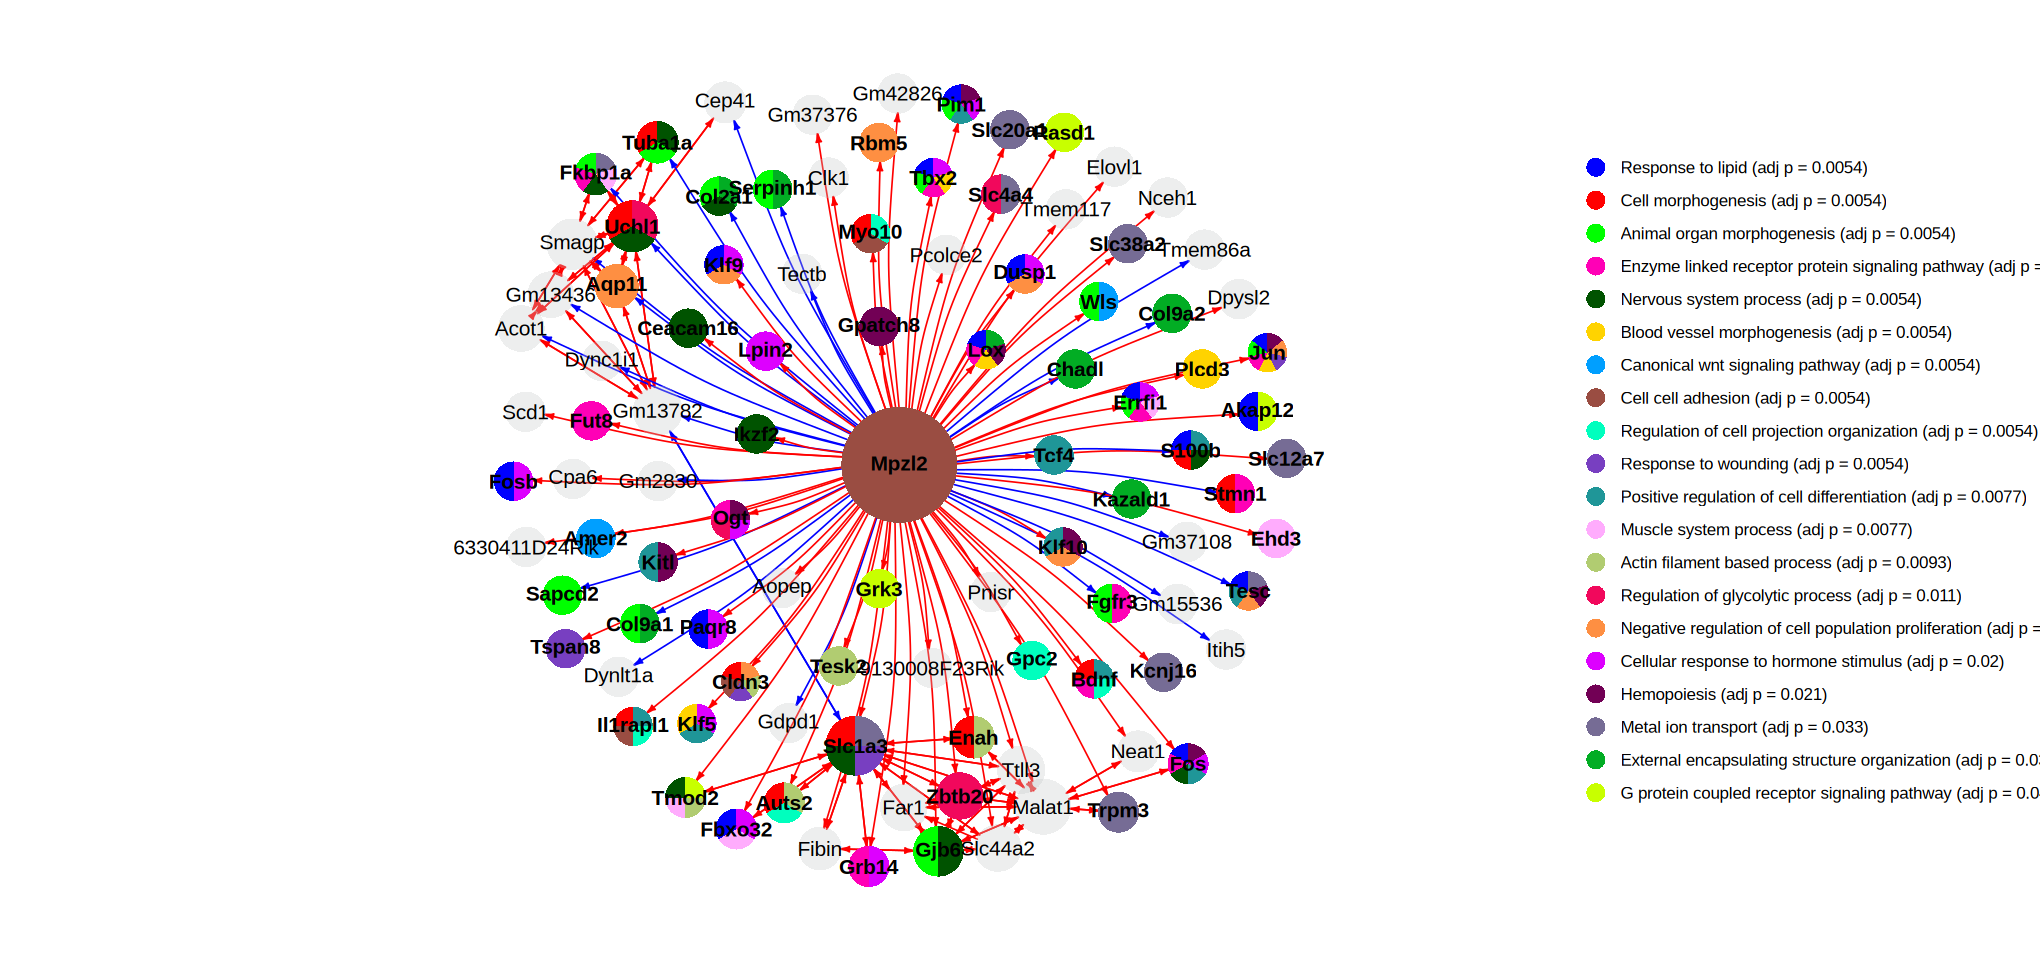

In [185]:
options(repr.plot.height=8, repr.plot.width=17)
.plotKO_pre(res, gKO = 'Mpzl2', fgsea_res = tenifold_gsea, annotate = T, q = 0.99, fdrThreshold = 0.05)

In [194]:
options(repr.plot.height=8, repr.plot.width=17)
svglite::svglite('fig/Mpzl2_egocentric_tenifold.svg', height=8, width=17)
.plotKO_pre(res, gKO = 'Mpzl2', fgsea_res = gobp_res %>% filter(pathway != 'scTenifold'), annotate = T, q = 0.99, fdrThreshold = 0.05) # fgsea_res = tenifold_gsea or gobp_res
dev.off()

agg_record_355816757 
                   2

devSVG 
     3

In [ ]:
.plotKO <- function(X, gKO, q = 0.99, annotate = TRUE, nCategories = 20, fdrThreshold = 0.05) {
    suppressMessages(require(pals))
    suppressMessages(require(enrichR))
    suppressMessages(require(igraph))
    suppressMessages(require(svglite))
    
    gList <- unique(c(gKO, X$diffRegulation$gene[X$diffRegulation$distance > 1e-10 & X$diffRegulation$p.adj < 0.05]))
    
    if (length(gList) > 0) {
        sCluster <- as.matrix(X$tensorNetworks$WT[gList, gList])
        koInfo <- sCluster[gKO, ]
        gList <- gList[!grepl('^mt-|^Rpl|^Rps', gList, ignore.case = TRUE)]
        sCluster[abs(sCluster) <= quantile(abs(sCluster), q)] <- 0
        sCluster[gKO, ] <- koInfo
        diag(sCluster) <- 0
        sCluster <- reshape2::melt(as.matrix(sCluster))
        colnames(sCluster) <- c('from', 'to', 'W')
        sCluster <- sCluster[sCluster$W != 0, ]
        netPlot <- igraph::graph_from_data_frame(sCluster, directed = TRUE)
        dPlot <- igraph::centr_degree(netPlot)$res
        W <- rep(1, nrow(sCluster))
        sG <- (names(igraph::V(netPlot))[dPlot > 1])[-1]
        W[sCluster$from %in% sG] <- 0.2
        W[sCluster$to %in% sG] <- 0.2
        W[sCluster$from %in% gKO] <- 1
        W[sCluster$from %in% gKO & sCluster$to %in% sG] <- 0.8
        set.seed(1)
        layPlot <- igraph::layout_with_fr(netPlot, weights = W)
        dPlot <- (dPlot / max(dPlot)) * 20
        
        if (isTRUE(annotate)) {
            enrichFunction <- function(X, fdrThreshold = fdrThreshold) {
                E <- enrichr(X, c('KEGG_2019_Human', 'GO_Biological_Process_2018', 'GO_Cellular_Component_2018', 'GO_Molecular_Function_2018', 'BioPlanet_2019', 'WikiPathways_2019_Human', 'Reactome_2016'))
                E <- do.call(rbind.data.frame, E)
                E <- E[E$Adjusted.P.value < fdrThreshold, ]
                E <- E[order(E$Adjusted.P.value), ]
                E$Term <- unlist(lapply(strsplit(E$Term, ''), function(X) {
                    X[1] <- toupper(X[1])
                    X <- paste0(X, collapse = '')
                    X <- gsub('\\([[:print:]]+\\)|Homo[[:print:]]+|WP[[:digit:]]+', '', X)
                    X <- gsub('\'s', '', X)
                    X <- unlist(strsplit(X, ','))[1]
                    X <- gsub('[[:blank:]]$', '', X)
                    return(X)
                }))
                selectedSet <- rep(FALSE, nrow(E))
                for (i in seq_len(nrow(E))) {
                    if (i == 1) {
                        selectedSet[i] <- TRUE
                    } else {
                        A <- unique(unlist(strsplit(E[which(selectedSet[seq_len(i)]), 'Genes'], ';')))
                        B <- unlist(strsplit(E[i, 'Genes'], ';'))
                        selectedSet[i] <- !all(B %in% A)
                    }
                }
                gSets <- table(toupper(E$Term))
                gSets <- names(gSets[gSets > 1])
                for (i in gSets) {
                    selectedSet[which(toupper(E$Term) %in% i)[-1]] <- FALSE
                }
                E <- E[selectedSet, ]
                if (nrow(E) > nCategories) {
                    E <- E[seq_len(nCategories), ]
                }
                return(E)
            }
            
            E <- enrichFunction(gList, fdrThreshold)
            
            if (isTRUE(nrow(E) > 0)) {
                tPlot <- strsplit(E$Genes, ';')
                pPlot <- matrix(0, nrow = length(igraph::V(netPlot)), ncol = nrow(E))
                rownames(pPlot) <- toupper(names(igraph::V(netPlot)))
                for (i in seq_along(tPlot)) {
                    pPlot[unlist(tPlot[i]), i] <- 1
                }
                pPlot <- lapply(seq_len(nrow(pPlot)), function(X) {
                    as.vector(pPlot[X, ])
                })
                names(pPlot) <- names(igraph::V(netPlot))
                tPlot <- unique(unlist(tPlot))
                eGenes <- toupper(names(igraph::V(netPlot))) %in% tPlot
                vColor <- rgb(195/255, 199/255, 198/255, 0.3)
                
                gb_cols <- pals::glasbey(32)
                gb_cols <- gb_cols[!gb_cols %in% c('#000033', '#201A01')]
                if (nrow(E) == 1) {
                    pieColors <- list(gb_cols[1])
                } else {
                    pieColors <- list(gb_cols[1:nrow(E)])
                }
                
                par(mar = c(0, 0, 0, 10), xpd = TRUE, family = 'Arial')
                
                suppressWarnings(plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.shape = ifelse(eGenes, 'pie', 'circle'), vertex.pie = pPlot, vertex.size = 10 + dPlot, vertex.pie.color = pieColors, vertex.label.family = 'Arial', vertex.label.font = ifelse(eGenes, 2, 1), edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = vColor, vertex.frame.color = NA))
                
                sigLevel <- formatC(E$Adjusted.P.value, digits = 2, format = 'g', width = 0, drop0trailing = TRUE)
                gSetNames <- lengths(strsplit(E$Genes, ';'))
                gSetNames <- paste0('(', gSetNames, ') ', E$Term, ' adj p = ', sigLevel)
                
                legend(x = 'right', inset = c(-1.1, 0), legend = gSetNames, bty = 'n', ncol = 1, cex = 0.8, pt.cex = 2, col = unlist(pieColors), pch = 16)
                
                svglite::svglite(file = 'fig/scTenifold_legend.svg', width = 8, height = 8)
                plot.new()
                par(family = 'Arial')
                legend(x = 'center', legend = gSetNames, bty = 'n', ncol = 1, cex = 0.8, pt.cex = 2, col = unlist(pieColors), pch = 16)
                dev.off()
                
            } else {
                par(mar = c(0, 0, 0, 0), family = 'Arial')
                plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.size = 10 + dPlot, vertex.label.family = 'Arial', edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
            }
        } else {
            par(mar = c(0, 0, 0, 0), family = 'Arial')
            plot(netPlot, layout = layPlot, edge.arrow.size = 0.2, vertex.label.color = 'black', vertex.size = 10 + dPlot, vertex.label.family = 'Arial', edge.color = ifelse(igraph::E(netPlot)$W > 0, 'red', 'blue'), edge.curved = ifelse(W == 0.2, 0, 0.1), vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
        }
    } else {
        netPlot <- matrix(0, 1, 1)
        rownames(netPlot) <- colnames(netPlot) <- gKO
        netPlot <- igraph::graph_from_adjacency_matrix(netPlot)
        par(mar = c(0, 0, 0, 0), family = 'Arial')
        plot(netPlot, edge.arrow.size = 0.2, vertex.size = 50, vertex.label.color = 'black', vertex.label.family = 'Arial', vertex.color = rgb(0, 188/255, 1, 0.3), vertex.frame.color = NA)
    }
}

Uploading data to Enrichr... Done.
  Querying KEGG_2019_Human... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying GO_Cellular_Component_2018... Done.
  Querying GO_Molecular_Function_2018... Done.
  Querying BioPlanet_2019... Done.
  Querying WikiPathways_2019_Human... Done.
  Querying Reactome_2016... Done.
Parsing results... Done.


agg_record_125846356 
                   2

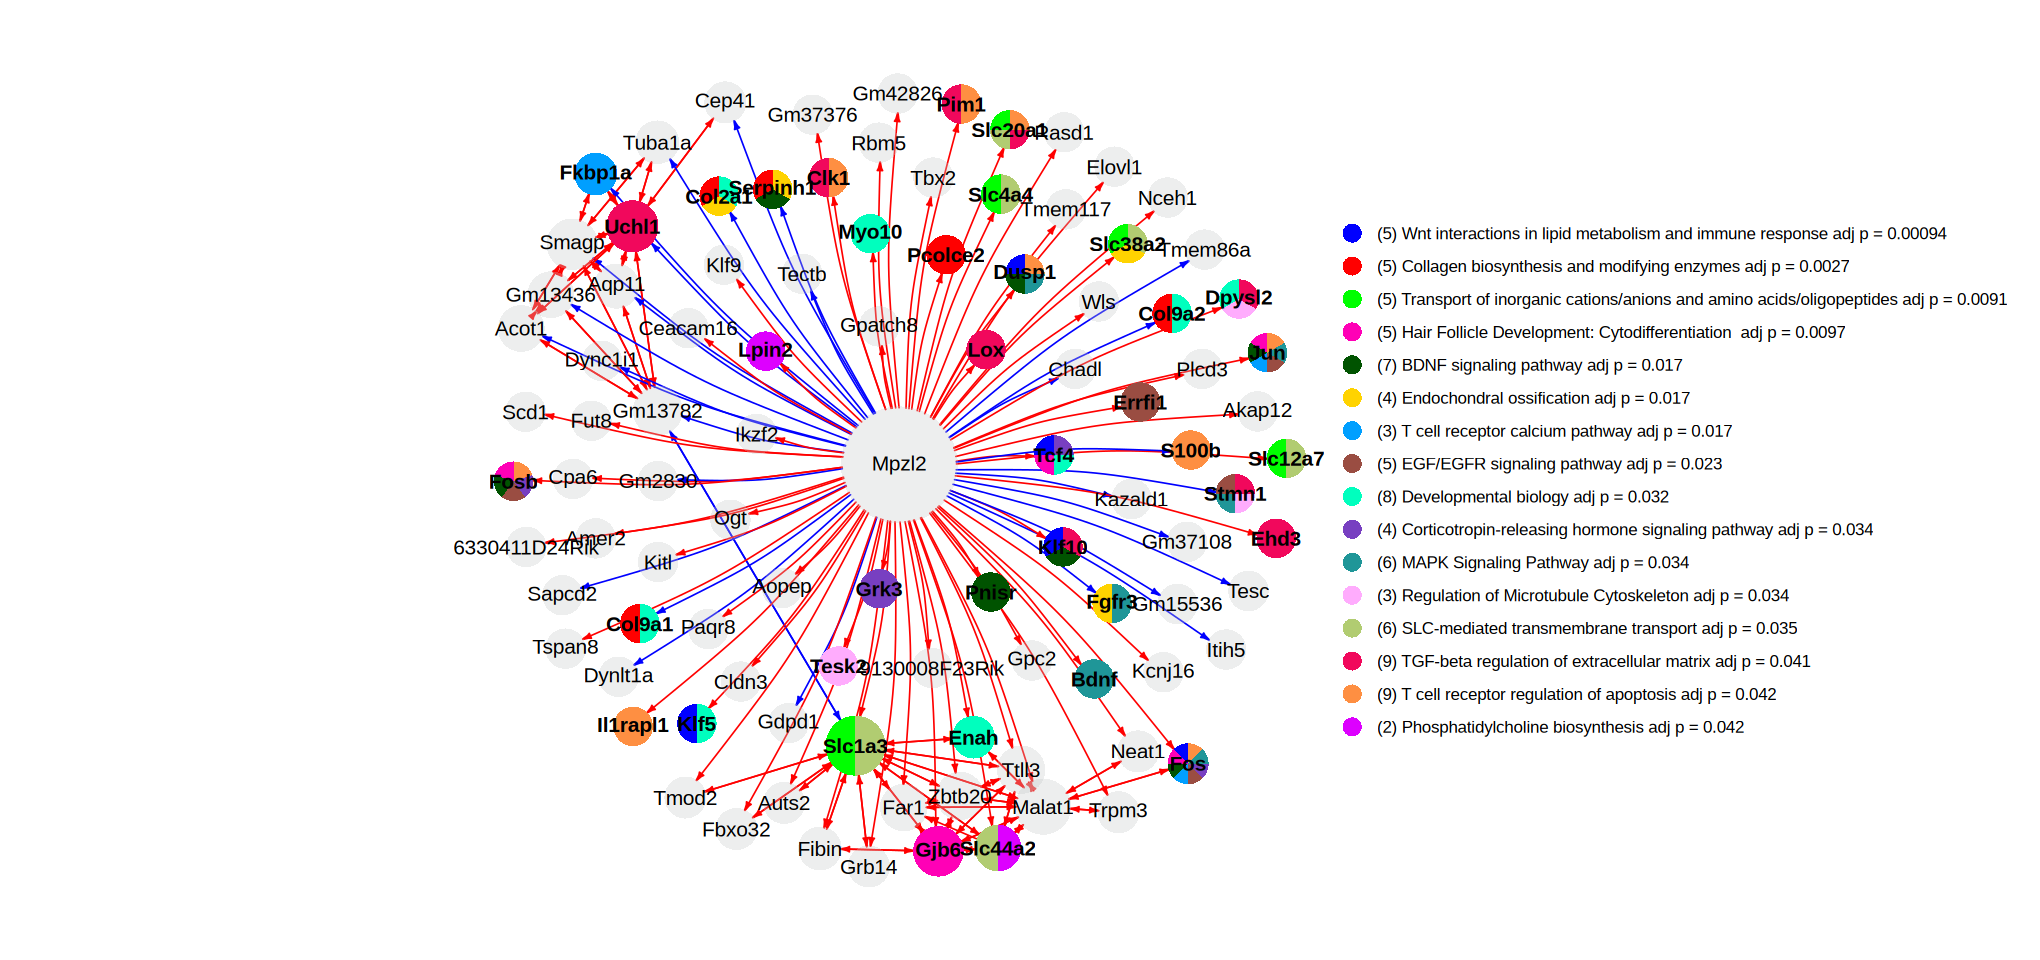

In [14]:
options(repr.plot.height=8, repr.plot.width=17)
.plotKO(res, gKO = 'Mpzl2', annotate = T, q = 0.99, fdrThreshold = 0.05)

In [16]:
svglite::svglite('fig/Mpzl2_egocentric_default.svg', height=8, width=17)
.plotKO(res, gKO = 'Mpzl2', annotate = T, q = 0.99, fdrThreshold = 0.05)
dev.off()

Uploading data to Enrichr... Done.
  Querying KEGG_2019_Human... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying GO_Cellular_Component_2018... Done.
  Querying GO_Molecular_Function_2018... Done.
  Querying BioPlanet_2019... Done.
  Querying WikiPathways_2019_Human... Done.
  Querying Reactome_2016... Done.
Parsing results... Done.


agg_record_484034555 
                   2